# Diseño Experimental y Principios Fundamentales

## Descripción del Curso
Este módulo cubre los principios fundamentales del diseño experimental aplicados a análisis multivariado en ambientes marinos y costeros.

## Contenidos
1. **Principios de Diseño Experimental**: Aleatoriedad, Control, Replicación
2. **ANOVA de Un Factor**: Comparación de medias entre grupos
3. **Post-Hoc Tests**: Análisis de pares de comparaciones
4. **Validación de Supuestos**: Normalidad, Homogeneidad de varianzas

## Principios Fundamentales del Diseño Experimental

### 1. Aleatoriedad (Randomization)
Asignación aleatoria de unidades experimentales a tratamientos para eliminar sesgos:
- Evita confusión de variables
- Garantiza independencia de observaciones
- Aumenta validez interna

### 2. Control
Aislamiento del efecto de variables no de interés:
- Grupos control (sin tratamiento)
- Variables covariadas si es necesario
- Estandarización de procedimientos

### 3. Replicación
Repetición del experimento/medición múltiples veces:
- Aumenta poder estadístico
- Reduce error experimental
- Permite estimación de variabilidad


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings

warnings.filterwarnings('ignore')

np.random.seed(42)
RANDOM_STATE = 42

sns.set_style("whitegrid")
print("✓ Librerías cargadas")


✓ Librerías cargadas


## Caso de Estudio: Técnicas de Restauración de Arrecifes de Coral

### Descripción del Problema
Los investigadores evalúan 3 técnicas diferentes para mejorar la tasa de crecimiento de coral en arrecifes dañados.

### Hipótesis
H₀: No hay diferencia significativa en tasas de crecimiento entre técnicas
H₁: Hay diferencias significativas entre al menos dos técnicas

### Técnicas Evaluadas
1. **Control**: Sin intervención (línea base)
2. **Técnica A**: Tratamiento químico estimulante
3. **Técnica B**: Estructuras de soporte físico
4. **Técnica C**: Introducción de algas simbióticas

### Diseño Experimental
- **Replicación**: 30 muestras por grupo
- **Asignación**: Aleatoria a uno de 4 grupos
- **Medida**: Crecimiento anual (cm/año)
- **Cegamiento**: Evaluador ciego a tratamiento


In [2]:
# Generación de Datos Experimentales

def generar_datos_coral(n_por_grupo=30, random_state=42):
    """Genera datos simulados de crecimiento de coral bajo diferentes tratamientos.

    Args:
        n_por_grupo (int): Número de réplicas por grupo
        random_state (int): Semilla para reproducibilidad

    Returns:
        pd.DataFrame: DataFrame con columnas 'Coral Growth' y 'Technique'
    """
    rng = np.random.default_rng(random_state)

    # Tasas de crecimiento simuladas (cm/año) con diferentes medias
    control_growth = rng.normal(loc=1.0, scale=0.3, size=n_por_grupo)  # Línea base
    technique_a = rng.normal(loc=2.0, scale=0.3, size=n_por_grupo)     # Mejora moderada
    technique_b = rng.normal(loc=1.5, scale=0.3, size=n_por_grupo)     # Mejora leve
    technique_c = rng.normal(loc=2.5, scale=0.3, size=n_por_grupo)     # Mejora significativa

    # Asegurar valores positivos
    control_growth = np.maximum(control_growth, 0.1)
    technique_a = np.maximum(technique_a, 0.1)
    technique_b = np.maximum(technique_b, 0.1)
    technique_c = np.maximum(technique_c, 0.1)

    # Crear DataFrame
    data = pd.DataFrame({
        'Coral Growth': np.concatenate([control_growth, technique_a, technique_b, technique_c]),
        'Technique': ['Control']*n_por_grupo + ['Technique A']*n_por_grupo +
                     ['Technique B']*n_por_grupo + ['Technique C']*n_por_grupo
    })

    return data

# Generar datos
data = generar_datos_coral(n_por_grupo=30, random_state=42)

print(f"Datos generados: {len(data)} observaciones, {data['Technique'].nunique()} grupos")
print(f"\nTamaños de grupo:")
print(data['Technique'].value_counts().sort_index())


Datos generados: 120 observaciones, 4 grupos

Tamaños de grupo:
Technique
Control        30
Technique A    30
Technique B    30
Technique C    30
Name: count, dtype: int64


In [3]:
# Análisis de Varianza (ANOVA)

print("\n" + "=" * 70)
print("ANÁLISIS DE VARIANZA (ANOVA) DE UN FACTOR")
print("=" * 70)

# Separar datos por grupo
control = data[data['Technique'] == 'Control']['Coral Growth']
tech_a = data[data['Technique'] == 'Technique A']['Coral Growth']
tech_b = data[data['Technique'] == 'Technique B']['Coral Growth']
tech_c = data[data['Technique'] == 'Technique C']['Coral Growth']

# Realizar ANOVA
f_statistic, p_value = stats.f_oneway(control, tech_a, tech_b, tech_c)

print(f"\nResultados ANOVA:")
print(f"  Estadístico F: {f_statistic:.4f}")
print(f"  p-valor: {p_value:.6f}")
print(f"  Significancia (α = 0.05): {'RECHAZAR H₀' if p_value < 0.05 else 'NO RECHAZAR H₀'}")

if p_value < 0.05:
    print(f"  → HAY diferencias significativas entre técnicas")
else:
    print(f"  → NO hay diferencias significativas entre técnicas")

# Estadísticas por grupo
print(f"\nEstadísticas por Técnica:")
print("-" * 70)
stats_summary = data.groupby('Technique')['Coral Growth'].agg([
    ('Media', 'mean'),
    ('Desv. Est.', 'std'),
    ('Mín', 'min'),
    ('Máx', 'max'),
    ('N', 'count')
])
print(stats_summary)

# Supuestos
print(f"\nValidación de Supuestos:")
print("-" * 70)

# Normalidad (Shapiro-Wilk test por grupo)
print("Normalidad (Shapiro-Wilk, H₀: distribución normal):")
for tech_name, group in [('Control', control), ('Técnica A', tech_a),
                          ('Técnica B', tech_b), ('Técnica C', tech_c)]:
    stat, p = stats.shapiro(group)
    print(f"  {tech_name:12} W={stat:.4f}, p={p:.6f} {'✓' if p > 0.05 else '✗'}")

# Homogeneidad de varianzas (Levene's test)
print(f"\nHomogeneidad de varianzas (Levene, H₀: varianzas iguales):")
levene_stat, levene_p = stats.levene(control, tech_a, tech_b, tech_c)
print(f"  Estadístico: {levene_stat:.4f}")
print(f"  p-valor: {levene_p:.6f}")
print(f"  Conclusión: {'✓ Varianzas iguales' if levene_p > 0.05 else '✗ Varianzas diferentes'}")



ANÁLISIS DE VARIANZA (ANOVA) DE UN FACTOR

Resultados ANOVA:
  Estadístico F: 211.1073
  p-valor: 0.000000
  Significancia (α = 0.05): RECHAZAR H₀
  → HAY diferencias significativas entre técnicas

Estadísticas por Técnica:
----------------------------------------------------------------------
                Media  Desv. Est.       Mín       Máx   N
Technique                                                
Control      1.005044    0.233025  0.414689  1.366762  30
Technique A  2.034127    0.241415  1.562853  2.642494  30
Technique B  1.469521    0.206096  0.995139  1.757393  30
Technique C  2.418825    0.254570  1.981804  2.980534  30

Validación de Supuestos:
----------------------------------------------------------------------
Normalidad (Shapiro-Wilk, H₀: distribución normal):
  Control      W=0.9651, p=0.416055 ✓
  Técnica A    W=0.9771, p=0.744367 ✓
  Técnica B    W=0.9403, p=0.092844 ✓
  Técnica C    W=0.9811, p=0.853882 ✓

Homogeneidad de varianzas (Levene, H₀: varianzas igual

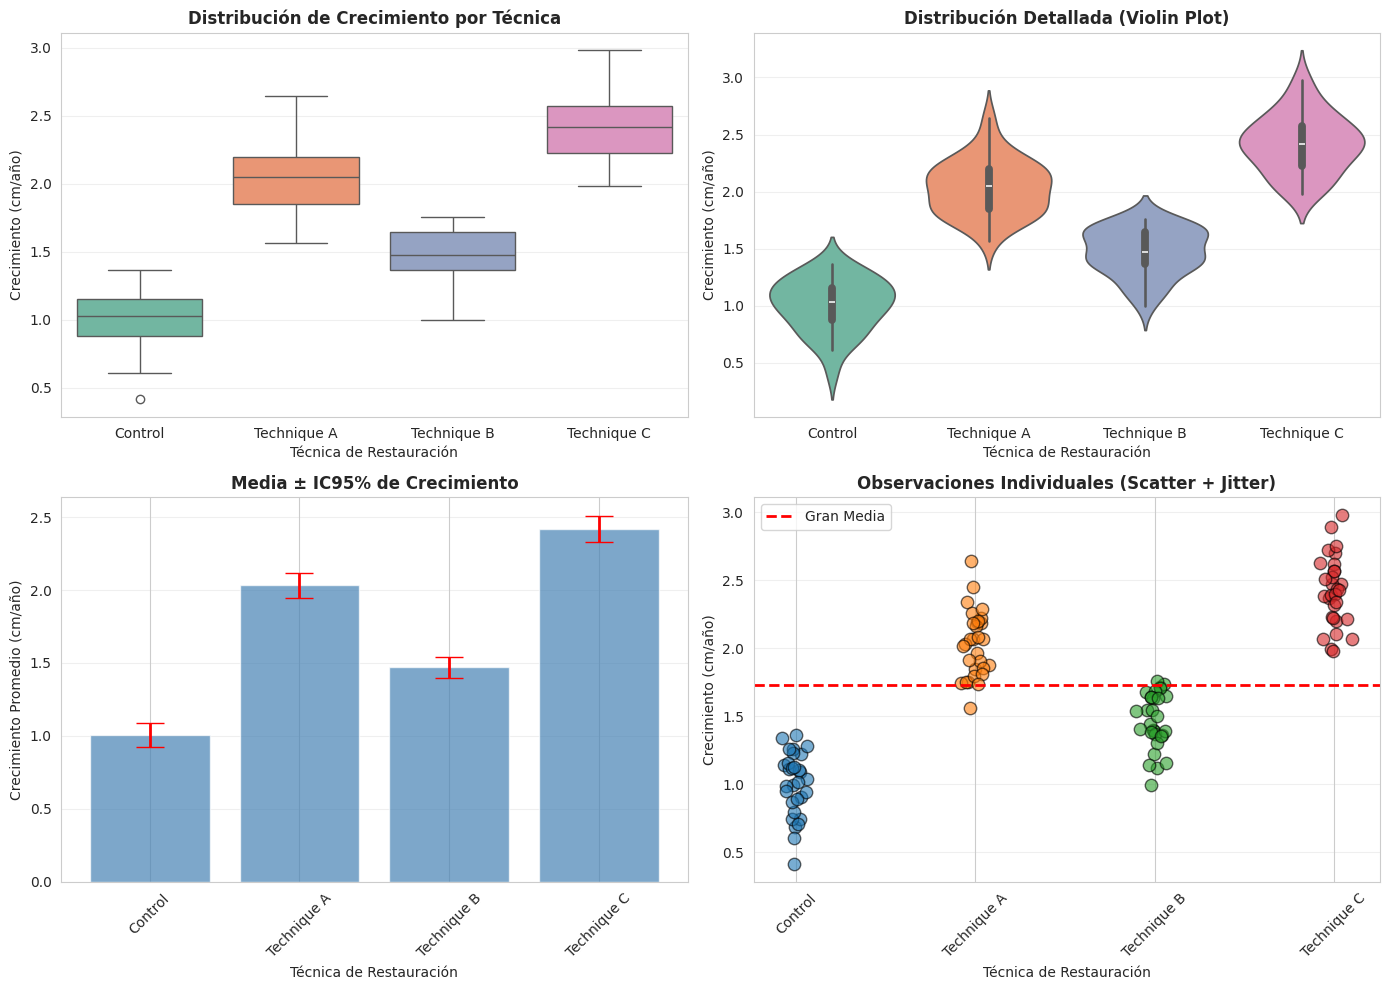

In [4]:
# Visualizaciones

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot
sns.boxplot(x='Technique', y='Coral Growth', data=data, ax=axes[0, 0],
           palette='Set2')
axes[0, 0].set_title('Distribución de Crecimiento por Técnica', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Crecimiento (cm/año)')
axes[0, 0].set_xlabel('Técnica de Restauración')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Violin plot
sns.violinplot(x='Technique', y='Coral Growth', data=data, ax=axes[0, 1],
              palette='Set2')
axes[0, 1].set_title('Distribución Detallada (Violin Plot)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Crecimiento (cm/año)')
axes[0, 1].set_xlabel('Técnica de Restauración')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Media con intervalo de confianza
means = data.groupby('Technique')['Coral Growth'].mean()
sems = data.groupby('Technique')['Coral Growth'].sem()
x_pos = range(len(means))
axes[1, 0].bar(x_pos, means.values, yerr=1.96*sems.values,
              capsize=10, color='steelblue', alpha=0.7,
              error_kw={'linewidth': 2, 'ecolor': 'red'})
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(means.index, rotation=45)
axes[1, 0].set_title('Media ± IC95% de Crecimiento', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Crecimiento Promedio (cm/año)')
axes[1, 0].set_xlabel('Técnica de Restauración')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Scatter plot con jitter
for i, tech in enumerate(sorted(data['Technique'].unique())):
    y = data[data['Technique'] == tech]['Coral Growth'].values
    x = np.random.normal(i, 0.04, size=len(y))
    axes[1, 1].scatter(x, y, alpha=0.6, s=80, edgecolors='black')
axes[1, 1].axhline(data['Coral Growth'].mean(), color='red', linestyle='--', linewidth=2,
                  label='Gran Media')
axes[1, 1].set_xticks(range(len(sorted(data['Technique'].unique()))))
axes[1, 1].set_xticklabels(sorted(data['Technique'].unique()), rotation=45)
axes[1, 1].set_title('Observaciones Individuales (Scatter + Jitter)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Crecimiento (cm/año)')
axes[1, 1].set_xlabel('Técnica de Restauración')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()



ANÁLISIS POST-HOC: TUKEY HSD (Honestly Significant Difference)

Resultados Tukey HSD:
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1      group2   meandiff p-adj  lower   upper  reject
-------------------------------------------------------------
    Control Technique A   1.0291   0.0  0.8713  1.1869   True
    Control Technique B   0.4645   0.0  0.3067  0.6223   True
    Control Technique C   1.4138   0.0   1.256  1.5716   True
Technique A Technique B  -0.5646   0.0 -0.7224 -0.4068   True
Technique A Technique C   0.3847   0.0  0.2269  0.5425   True
Technique B Technique C   0.9493   0.0  0.7915  1.1071   True
-------------------------------------------------------------

Tabla de Comparaciones Pares:
    Grupo 1     Grupo 2  Diferencia Media  p-adj  Inferior  Superior  Rechazo H₀
    Control Technique A            1.0291    0.0    0.8713    1.1869        True
    Control Technique B            0.4645    0.0    0.3067    0.6223        True
    Control Techniq

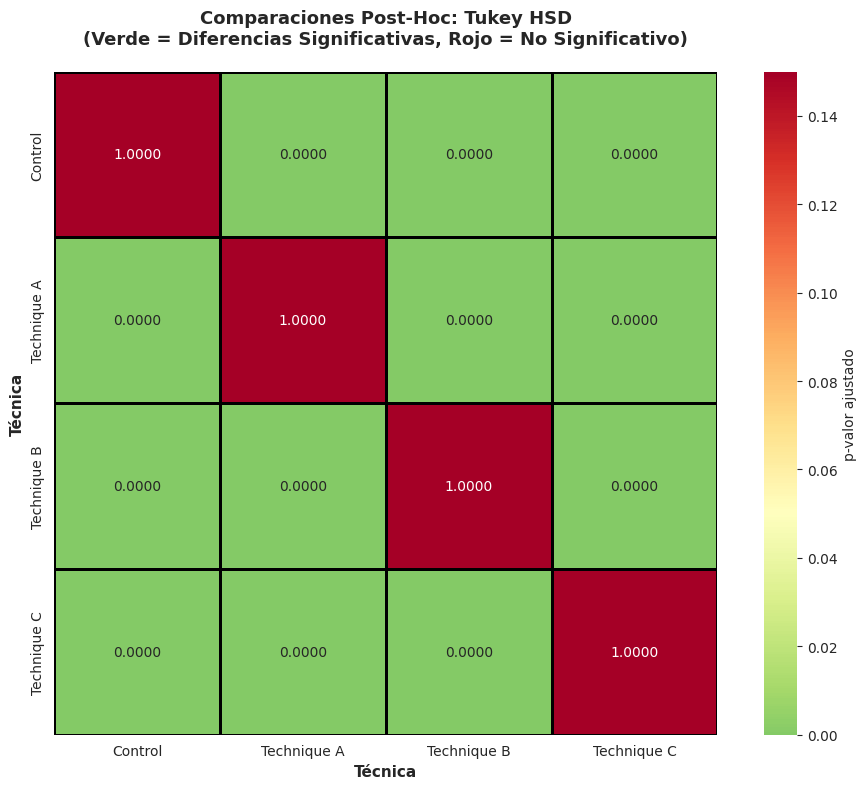


INTERPRETACIÓN:
Verde (p < 0.05): Diferencias significativas entre pares
Rojo (p ≥ 0.05): Diferencias NO significativas


In [5]:
# Análisis Post-Hoc: Comparaciones Pares (Tukey HSD)

print("\n" + "=" * 70)
print("ANÁLISIS POST-HOC: TUKEY HSD (Honestly Significant Difference)")
print("=" * 70)

# Realizar Tukey HSD
tukey_result = pairwise_tukeyhsd(
    endog=data['Coral Growth'],
    groups=data['Technique'],
    alpha=0.05
)

print("\nResultados Tukey HSD:")
print(tukey_result)

# Extraer resultados en formato de tabla
tukey_df = pd.DataFrame(data=tukey_result.summary().data[1:],
                        columns=tukey_result.summary().data[0])
tukey_df.columns = ['Grupo 1', 'Grupo 2', 'Diferencia Media', 'p-adj', 'Inferior', 'Superior', 'Rechazo H₀']

# Convertir a tipos numéricos
for col in ['Diferencia Media', 'p-adj', 'Inferior', 'Superior']:
    tukey_df[col] = pd.to_numeric(tukey_df[col], errors='coerce')

print("\nTabla de Comparaciones Pares:")
print(tukey_df.to_string(index=False))

# Crear matriz de p-valores para heatmap
grupos = sorted(data['Technique'].unique())
p_matriz = pd.DataFrame(index=grupos, columns=grupos, dtype=float)

# Llenar diagonal con 1.0
np.fill_diagonal(p_matriz.values, 1.0)

# Llenar matriz con p-valores
for _, row in tukey_df.iterrows():
    g1, g2 = row['Grupo 1'], row['Grupo 2']
    p_val = float(row['p-adj'])
    p_matriz.loc[g1, g2] = p_val
    p_matriz.loc[g2, g1] = p_val

# Convertir a float
p_matriz = p_matriz.astype(float)

print("\nMatriz de p-valores (Tukey):")
print(p_matriz)

# Crear heatmap mejorado
fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap con anotaciones
sns.heatmap(p_matriz, annot=True, fmt='.4f', cmap='RdYlGn_r',
           vmin=0, vmax=0.15, center=0.05,
           xticklabels=True, yticklabels=True,
           cbar_kws={'label': 'p-valor ajustado'},
           ax=ax, linewidths=1, linecolor='black',
           square=True)

ax.set_title('Comparaciones Post-Hoc: Tukey HSD\n(Verde = Diferencias Significativas, Rojo = No Significativo)',
            fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Técnica', fontsize=11, fontweight='bold')
ax.set_ylabel('Técnica', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Interpretación
print("\n" + "=" * 70)
print("INTERPRETACIÓN:")
print("=" * 70)
print("Verde (p < 0.05): Diferencias significativas entre pares")
print("Rojo (p ≥ 0.05): Diferencias NO significativas")


In [6]:
# Tamaño de Efecto

print("\n" + "=" * 70)
print("MEDIDAS DE TAMAÑO DE EFECTO")
print("=" * 70)

# Eta-squared (η²) = Varianza explicada por el tratamiento
def calcular_eta_squared(grupos):
    """Calcula eta-squared (proporción de varianza explicada)"""
    valores_totales = np.concatenate(grupos)
    gran_media = valores_totales.mean()
    ss_entre = sum(len(g) * (g.mean() - gran_media)**2 for g in grupos)
    ss_total = sum((x - gran_media)**2 for x in valores_totales)
    return ss_entre / ss_total

eta_sq = calcular_eta_squared([control, tech_a, tech_b, tech_c])
print(f"\nEta-squared (η²): {eta_sq:.4f}")
print(f"  Interpretación: {eta_sq*100:.2f}% de la varianza en crecimiento")
print(f"                 se explica por la técnica de restauración")

# Omega-squared (menos sesgado)
k = 4  # número de grupos
n_total = len(data)
ms_between = sum(len(g) * (g.mean() - data['Coral Growth'].mean())**2 for g in [control, tech_a, tech_b, tech_c]) / (k - 1)
ms_within = sum(sum((x - g.mean())**2) for g in [control, tech_a, tech_b, tech_c]) / (n_total - k)
f_stat = ms_between / ms_within
omega_sq = (f_stat - 1) / (f_stat + (n_total - k) / (k - 1))
omega_sq = max(0, omega_sq)  # No puede ser negativo

print(f"\nOmega-squared (ω²): {omega_sq:.4f}")
print(f"  (Estimador menos sesgado, más conservador)")

# Clasificación de tamaño de efecto
print(f"\nClasificación (Cohen):")
if eta_sq < 0.01:
    print(f"  Tamaño de efecto PEQUEÑO (η² < 0.01)")
elif eta_sq < 0.06:
    print(f"  Tamaño de efecto MEDIO (0.01 ≤ η² < 0.06)")
else:
    print(f"  Tamaño de efecto GRANDE (η² ≥ 0.06)")



MEDIDAS DE TAMAÑO DE EFECTO

Eta-squared (η²): 0.8452
  Interpretación: 84.52% de la varianza en crecimiento
                 se explica por la técnica de restauración

Omega-squared (ω²): 0.1102
  (Estimador menos sesgado, más conservador)

Clasificación (Cohen):
  Tamaño de efecto GRANDE (η² ≥ 0.06)


## Ejercicios para el Estudiante

### Ejercicio 1: Validación de Supuestos Adicionales
1. Realiza un Q-Q plot para verificar normalidad visualmente
2. Calcula residuos y visualiza su distribución
3. ¿Hay puntos influyentes o outliers?
4. Prueba ANOVA no paramétrica (Kruskal-Wallis) para comparar

### Ejercicio 2: Análisis de Poder Estadístico
1. ¿Cuán probable es detectar una diferencia real de 0.5 cm/año?
2. Calcula el tamaño de muestra necesario para poder = 0.90
3. ¿Qué sucede si el tamaño de efecto es más pequeño?

### Ejercicio 3: Contraste Personalizado
1. Crea un contraste específico: Control vs Todas las Técnicas
2. ¿Es significativa la diferencia?
3. Compara con resultados Tukey

---

**Nota**: La validación de supuestos es crítica para la validez de ANOVA. Considera transformaciones (log, sqrt) si los supuestos se violan.
